# ⚽ Football Match Outcome Predictor

This notebook builds a **Random Forest Classifier** to predict the outcome of a football match (Home Win / Away Win / Draw) based on match scores.

---

## 📋 Table of Contents
1. [Imports & Setup](#1-imports)
2. [Load & Explore Data](#2-data)
3. [Feature Engineering](#3-features)
4. [Data Visualization](#4-viz)
5. [Train / Test Split](#5-split)
6. [Model Training](#6-train)
7. [Model Evaluation](#7-eval)
8. [Predict a Match](#8-predict)

## 1. 📦 Imports & Setup <a name="1-imports"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
print("✅ All libraries loaded.")

✅ All libraries loaded.


## 2. 📂 Load & Explore Data <a name="2-data"></a>

In [5]:
df = pd.read_csv("football_match_dataset.csv")

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
print("--- First 5 rows ---")
df.head()

Dataset shape: 5 rows × 6 columns

--- First 5 rows ---


,home_team,away_team,home_score,away_score,tournament,result
0,Argentina,Germany,2,1,Friendly,Home Win
1,France,Portugal,1,1,Nations League,Draw
2,Brazil,Italy,3,2,Qualifier,Home Win
3,Spain,Netherlands,0,1,Friendly,Away Win
4,England,Belgium,2,2,Qualifier,Draw


In [6]:
print("--- Dataset Info ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Basic Statistics ---")
df.describe()

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   home_team   5 non-null      object
 1   away_team   5 non-null      object
 2   home_score  5 non-null      int64 
 3   away_score  5 non-null      int64 
 4   tournament  5 non-null      object
 5   result      5 non-null      object
dtypes: int64(2), object(4)
memory usage: 372.0+ bytes

--- Missing Values ---
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
result        0
dtype: int64

--- Basic Statistics ---


,home_score,away_score
count,5.000000,5.000000
mean,1.600000,1.400000
std,1.140175,0.547723
min,0.000000,1.000000
25%,1.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,3.000000,2.000000


## 3. 🔧 Feature Engineering <a name="3-features"></a>

We derive a `result` column from the scores:
- **0** → Home Win
- **1** → Away Win
- **2** → Draw

In [7]:
def result(row):
    if row['home_score'] > row['away_score']:
        return 0   # Home Win
    elif row['home_score'] < row['away_score']:
        return 1   # Away Win
    else:
        return 2   # Draw

df['result'] = df.apply(result, axis=1)

LABEL_MAP = {0: "Home Win", 1: "Away Win", 2: "Draw"}
df['result_label'] = df['result'].map(LABEL_MAP)

print("Result distribution:")
print(df['result_label'].value_counts())

Result distribution:
result_label
Home Win    2
Draw        2
Away Win    1
Name: count, dtype: int64


## 4. 📊 Data Visualization <a name="4-viz"></a>

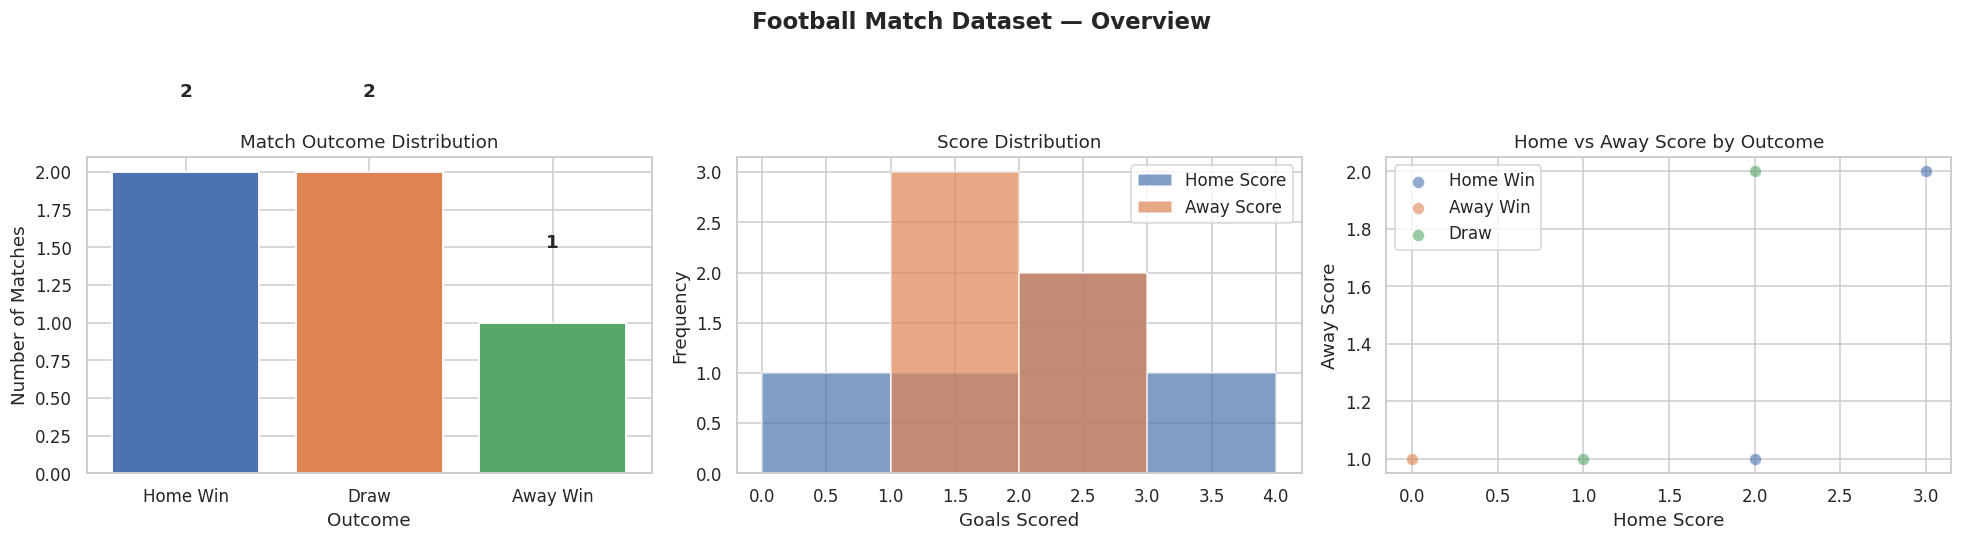

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Football Match Dataset — Overview", fontsize=15, fontweight="bold")

# --- Plot 1: Outcome distribution (bar) ---
counts = df['result_label'].value_counts()
colors = ["#4C72B0", "#DD8452", "#55A868"]
axes[0].bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=1.2)
axes[0].set_title("Match Outcome Distribution")
axes[0].set_xlabel("Outcome")
axes[0].set_ylabel("Number of Matches")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# --- Plot 2: Home vs Away score distributions ---
axes[1].hist(df['home_score'], bins=range(0, df['home_score'].max() + 2),
             alpha=0.7, label='Home Score', color='#4C72B0', edgecolor='white')
axes[1].hist(df['away_score'], bins=range(0, df['away_score'].max() + 2),
             alpha=0.7, label='Away Score', color='#DD8452', edgecolor='white')
axes[1].set_title("Score Distribution")
axes[1].set_xlabel("Goals Scored")
axes[1].set_ylabel("Frequency")
axes[1].legend()

# --- Plot 3: Home score vs Away score scatter ---
palette = {"Home Win": "#4C72B0", "Away Win": "#DD8452", "Draw": "#55A868"}
for label, color in palette.items():
    subset = df[df['result_label'] == label]
    axes[2].scatter(subset['home_score'], subset['away_score'],
                    label=label, color=color, alpha=0.6, edgecolors='white', linewidths=0.4, s=60)
axes[2].set_title("Home vs Away Score by Outcome")
axes[2].set_xlabel("Home Score")
axes[2].set_ylabel("Away Score")
axes[2].legend()

plt.tight_layout()
plt.show()

## 5. ✂️ Train / Test Split <a name="5-split"></a>

In [9]:
X = df[['home_score', 'away_score']]
y = df['result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

Training samples : 4
Test samples     : 1


## 6. 🌲 Model Training <a name="6-train"></a>

In [10]:
model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
model.fit(X_train, y_train)

print("✅ Model trained successfully.")
print(f"   Number of trees : {model.n_estimators}")
print(f"   Features used   : {list(X.columns)}")

✅ Model trained successfully.
   Number of trees : 100
   Features used   : ['home_score', 'away_score']


## 7. 📈 Model Evaluation <a name="7-eval"></a>

In [11]:
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"🎯 Test Accuracy: {accuracy:.2%}\n")
print("--- Classification Report ---")
target_names = [LABEL_MAP[i] for i in sorted(LABEL_MAP)]
print(classification_report(y_test, predictions, target_names=target_names))

🎯 Test Accuracy: 0.00%

--- Classification Report ---


ValueError: Number of classes, 2, does not match size of target_names, 3. Try specifying the labels parameter

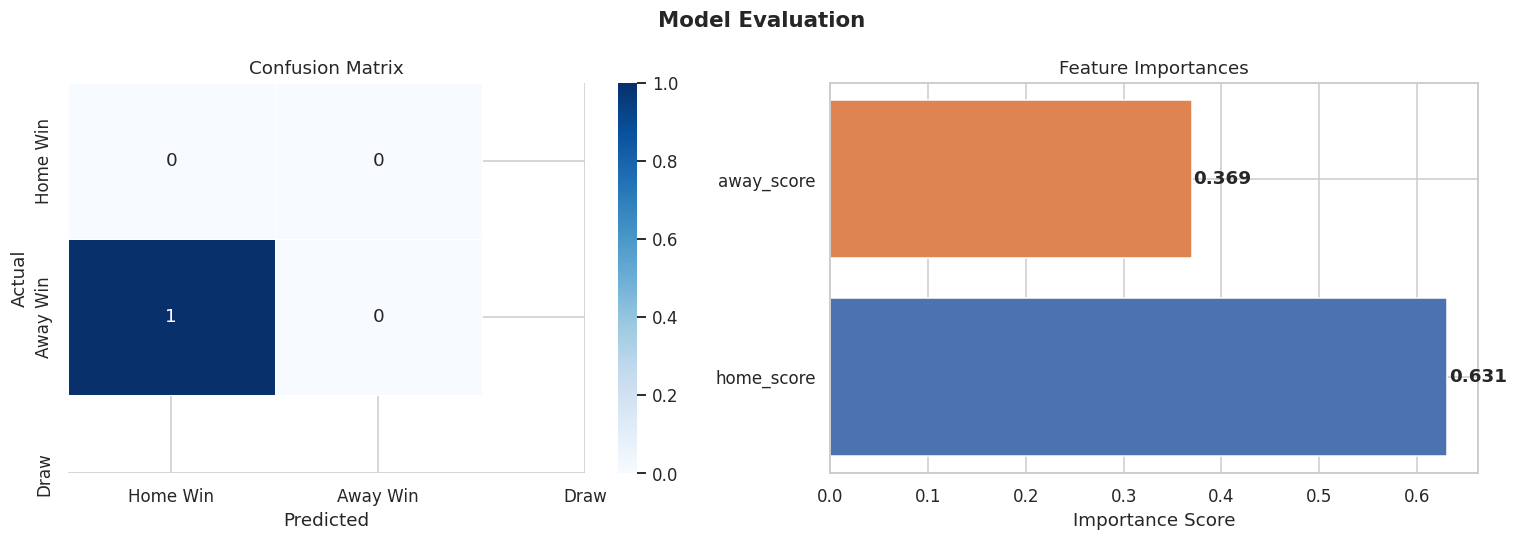

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Evaluation", fontsize=14, fontweight="bold")

# --- Plot 1: Confusion Matrix ---
cm = confusion_matrix(y_test, predictions)
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names,
    ax=axes[0],
    linewidths=0.5
)
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# --- Plot 2: Feature Importances ---
importances = model.feature_importances_
feat_names = X.columns
axes[1].barh(feat_names, importances, color=["#4C72B0", "#DD8452"], edgecolor='white')
axes[1].set_title("Feature Importances")
axes[1].set_xlabel("Importance Score")
for i, v in enumerate(importances):
    axes[1].text(v + 0.002, i, f"{v:.3f}", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. 🔮 Predict a Match <a name="8-predict"></a>

Enter the home and away score of a match to predict its outcome.

In [13]:
# ✏️ Change these values to predict any match
home_goals = 2
away_goals = 1

sample = [[home_goals, away_goals]]
pred = model.predict(sample)[0]
proba = model.predict_proba(sample)[0]

print(f"Match: Home {home_goals} – {away_goals} Away")
print(f"\n🏆 Predicted Outcome : {LABEL_MAP[pred]}")
print("\nProbabilities:")
for idx, label in LABEL_MAP.items():
    bar = "█" * int(proba[idx] * 30)
    print(f"  {label:<12} {bar:<30}  {proba[idx]:.1%}")

Match: Home 2 – 1 Away

🏆 Predicted Outcome : Home Win

Probabilities:
  Home Win     █████████████████████           71.0%
  Away Win     ████                            15.0%
  Draw         ████                            14.0%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [15]:
from pyngrok import ngrok, conf

ngrok.set_auth_token("3DgUqwgiTSZuU2L8ICU04CxPbsi_6qVScVvSp2sKqGdSBk8v7")  # ← paste your token

public_url = ngrok.connect(5000).public_url
print(f"API live at: {public_url}/predict")

API live at: https://zit-crudely-gallantly.ngrok-free.dev/predict


In [16]:
# Install dependencies
!pip install flask flask-cors pyngrok --quiet

from flask import Flask, request, jsonify
from flask_cors import CORS
from pyngrok import ngrok
import threading

app = Flask(__name__)
CORS(app)  # allows your HTML file to call the API

@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json()
    home = data['home_score']
    away = data['away_score']

    sample = [[home, away]]
    pred = model.predict(sample)[0]
    proba = model.predict_proba(sample)[0].tolist()

    return jsonify({
        'prediction': int(pred),
        'label': LABEL_MAP[int(pred)],
        'probabilities': {
            'home_win': round(proba[0], 3),
            'away_win': round(proba[1], 3),
            'draw':     round(proba[2], 3)
        }
    })

# Start Flask in a background thread
threading.Thread(target=lambda: app.run(port=5000)).start()

# Get public URL via ngrok
public_url = ngrok.connect(5000).public_url
print(f"API live at: {public_url}/predict")

 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.


API live at: https://zit-crudely-gallantly.ngrok-free.dev/predict
